# Exploratory Data Analysis

In [2]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# import data
data = pd.read_csv("/Users/jiehni/monash/ADS2001_GROUPMC3/data/processed/melb.csv")
data.head()

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Speed (km/h),...,WindDir_NNW,WindDir_NW,WindDir_S,WindDir_SE,WindDir_SSE,WindDir_SSW,WindDir_SW,WindDir_W,WindDir_WNW,WindDir_WSW
0,2011,1,1.0,0.0,4.0,24.8,0.0,14.0,51.0,11,...,False,False,False,True,False,False,False,False,False,False
1,2011,1,1.0,0.0,14.0,24.8,0.0,13.3,48.0,11,...,False,False,False,True,False,False,False,False,False,False
2,2011,1,1.0,0.0,24.0,24.9,0.0,13.3,48.0,11,...,False,False,False,True,False,False,False,False,False,False
3,2011,1,1.0,0.0,34.0,24.7,0.0,13.4,49.0,11,...,False,False,False,True,False,False,False,False,False,False
4,2011,1,1.0,0.0,44.0,24.1,0.0,13.3,51.0,9,...,False,False,False,False,False,False,False,False,False,False


In [3]:
# add target variable
data["Rainfall since 9 am (mm)"] = pd.to_numeric(data["Rainfall since 9 am (mm)"], errors="coerce")
data["Rain"] = (data["Rainfall since 9 am (mm)"] > 0).astype(int)
data["Rain"] = pd.to_numeric(data["Rain"])

In [4]:
# convert datetime variable to datetime
data["Datetime"] = pd.to_datetime(data["Datetime"])

# check variable correlation
data.corr(numeric_only=True)

,Year,Month,Day,Hour,Minute,Air Temp (degrees C),Apparent Temp (degrees C),Dew Pt Temp (degrees C),Humidity (%),Wind Speed (km/h),...,WindDir_NNW,WindDir_NW,WindDir_S,WindDir_SE,WindDir_SSE,WindDir_SSW,WindDir_SW,WindDir_W,WindDir_WNW,WindDir_WSW
Year,1.000000,-0.041535,-0.037308,-0.007562,-0.115460,-0.004157,0.441984,0.063272,0.067133,0.005639,...,-0.029279,-0.004347,-0.001016,-0.007164,-0.008446,0.022473,0.002230,-0.011410,-0.004644,-0.006004
Month,-0.041535,1.000000,0.043673,0.001505,-0.002228,-0.216659,-0.124883,-0.255362,0.070819,0.018823,...,0.013306,0.004369,-0.027393,-0.028778,-0.029348,-0.006420,0.015489,-0.000917,-0.001858,0.017875
Day,-0.037308,0.043673,1.000000,-0.001764,0.006408,0.004198,-0.008109,0.009219,-0.002008,-0.019327,...,0.007366,0.011444,-0.011107,-0.006564,-0.002940,-0.005684,-0.006171,-0.003099,0.008563,-0.010398
Hour,-0.007562,0.001505,-0.001764,1.000000,-0.014144,0.229110,0.113887,0.006892,-0.269377,0.108389,...,-0.031509,-0.030299,0.187406,0.030864,0.100865,0.059176,-0.027331,-0.062475,-0.073778,-0.049360
Minute,-0.115460,-0.002228,0.006408,-0.014144,1.000000,0.009664,-0.048614,-0.005329,-0.017060,0.002844,...,0.005231,-0.001254,0.001541,0.002187,0.002731,0.000331,0.000855,-0.000540,-0.002987,0.000704
Air Temp (degrees C),-0.004157,-0.216659,0.004198,0.229110,0.009664,1.000000,0.617259,0.459562,-0.759445,0.269369,...,0.006403,-0.014001,0.059502,0.056119,0.078331,-0.022112,-0.087079,-0.111135,-0.071030,-0.112004
Apparent Temp (degrees C),0.441984,-0.124883,-0.008109,0.113887,-0.048614,0.617259,1.000000,0.400887,-0.373275,0.058741,...,0.003592,-0.000476,0.018826,0.037290,0.042799,-0.007976,-0.051476,-0.058593,-0.028169,-0.073898
Dew Pt Temp (degrees C),0.063272,-0.255362,0.009219,0.006892,-0.005329,0.459562,0.400887,1.000000,0.191859,-0.105261,...,-0.037096,-0.021469,0.071980,0.004436,0.023456,0.055262,0.004347,-0.035324,-0.021226,-0.037463
Humidity (%),0.067133,0.070819,-0.002008,-0.269377,-0.017060,-0.759445,-0.373275,0.191859,1.000000,-0.380542,...,-0.018059,0.009635,-0.049698,-0.070983,-0.093302,0.050822,0.097634,0.103217,0.072098,0.100432
Wind Speed (km/h),0.005639,0.018823,-0.019327,0.108389,0.002844,0.269369,0.058741,-0.105261,-0.380542,1.000000,...,-0.026094,-0.071186,0.035876,-0.020711,0.033649,-0.057720,-0.044659,-0.075776,-0.100727,-0.029176


As can be seen in the correlation table, air temp (degrees C), humidity (%) and rainfall since 9am (mm) variables have strongest correlation with the target variable rain.


<Axes: >

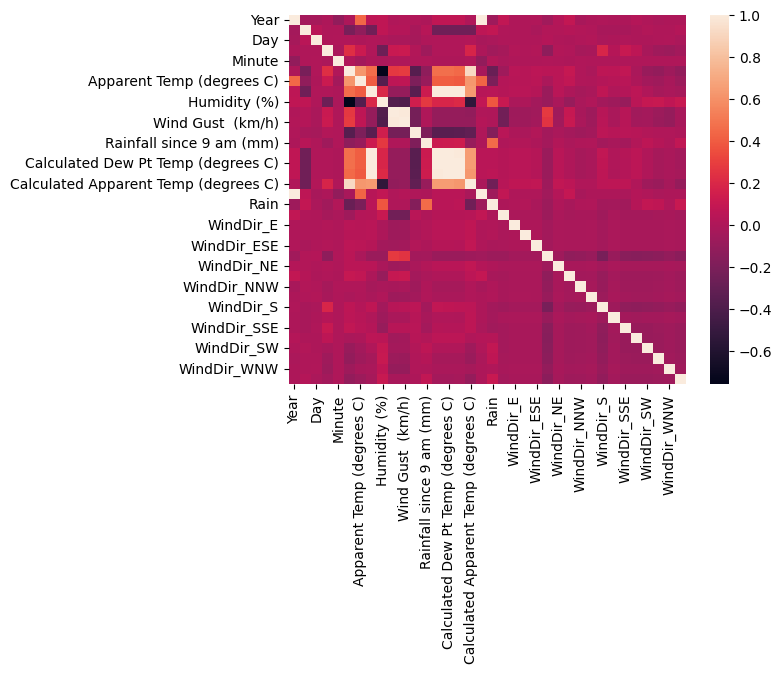

In [16]:
sns.heatmap(data.corr())

### Monthly statistics 

In [32]:
# obtain daily total rainfall
df = data.sort_values(['Year', 'Month', 'Day', 'Hour', 'Minute'])

# latest recording each day
daily_rain = df.groupby(['Year', 'Month', 'Day']).tail(1)[
    ['Year', 'Month', 'Day', 'Rainfall since 9 am (mm)']
].copy()

# monthly rainfall stats
monthly = daily_rain.groupby(['Year', 'Month'])['Rainfall since 9 am (mm)'].sum().reset_index()
monthly.rename(columns={'Rainfall since 9 am (mm)': 'TotalRainfall'}, inplace=True)

avg_rain = daily_rain.groupby(['Year', 'Month'])['Rainfall since 9 am (mm)'].mean().reset_index()
avg_rain.rename(columns={'Rainfall since 9 am (mm)': 'AvgDailyRainfall'}, inplace=True)

daily_rain['RainDay'] = (daily_rain['Rainfall since 9 am (mm)'] > 0).astype(int)

rain_days = daily_rain.groupby(['Year', 'Month'])['RainDay'].sum().reset_index()
rain_days.rename(columns={'RainDay': 'RainyDays'}, inplace=True)

# join tables
monthly = monthly.merge(avg_rain, on=['Year', 'Month'])
monthly = monthly.merge(rain_days, on=['Year', 'Month'])

In [33]:
# monthly climate averages
monthly_climate = df.groupby(['Year', 'Month']).agg({
    'Air Temp (degrees C)': 'mean',
    'Apparent Temp (degrees C)': 'mean',
    'Dew Pt Temp (degrees C)': 'mean',
    'Humidity (%)': 'mean',
    'Wind Speed (km/h)': 'mean',
    'Wind Gust  (km/h)': 'mean',
    'MSLP (hPa)': 'mean'
}).reset_index()

# rename columns
monthly_climate.rename(columns={
    'Air Temp (degrees C)': 'AvgAirTemp',
    'Apparent Temp (degrees C)': 'AvgApparentTemp',
    'Dew Pt Temp (degrees C)': 'AvgDewPointTemp',
    'Humidity (%)': 'AvgHumidity',
    'Wind Speed (km/h)': 'AvgWindSpeed',
    'Wind Gust  (km/h)': 'AvgWindGust',
    'MSLP (hPa)': 'AvgMSLP'
}, inplace=True)

# merge tables
monthly = monthly.merge(monthly_climate, on=['Year', 'Month'])
monthly.head()

,Year,Month,TotalRainfall,AvgDailyRainfall,RainyDays,AvgAirTemp,AvgApparentTemp,AvgDewPointTemp,AvgHumidity,AvgWindSpeed,AvgWindGust,AvgMSLP
0,2011,1,70.0,2.258065,9,21.447324,0.0,14.041187,64.843805,16.987493,19.811809,1011.050553
1,2011,2,26.4,0.942857,13,20.933896,0.0,14.316618,67.639032,15.574101,18.065664,1014.094497
2,2011,3,19.4,0.625806,8,19.213039,0.0,12.261953,65.967888,17.373986,20.079468,1015.366591
3,2011,4,41.8,1.393333,11,16.358959,0.0,10.124172,68.659567,16.574375,18.809669,1022.634990
4,2011,5,47.6,1.762963,13,13.321645,0.0,9.316812,77.299229,14.741902,16.808740,1018.192596


In [34]:
# new column for how many days recorder each month
days_recorded = daily_rain.groupby(['Year', 'Month']).size().reset_index(name='DaysRecorded')
monthly = monthly.merge(days_recorded, on=['Year', 'Month'])

In [27]:
monthly.info()
monthly.head(12)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Year              135 non-null    int64  
 1   Month             135 non-null    int64  
 2   TotalRainfall     135 non-null    float64
 3   AvgDailyRainfall  135 non-null    float64
 4   RainyDays         135 non-null    int64  
 5   AvgAirTemp        135 non-null    float64
 6   AvgApparentTemp   135 non-null    float64
 7   AvgDewPointTemp   135 non-null    float64
 8   AvgHumidity       135 non-null    float64
 9   AvgWindSpeed      135 non-null    float64
 10  AvgWindGust       135 non-null    float64
 11  AvgMSLP           135 non-null    float64
 12  DaysRecorded      135 non-null    int64  
dtypes: float64(9), int64(4)
memory usage: 13.8 KB


,Year,Month,TotalRainfall,AvgDailyRainfall,RainyDays,AvgAirTemp,AvgApparentTemp,AvgDewPointTemp,AvgHumidity,AvgWindSpeed,AvgWindGust,AvgMSLP,DaysRecorded
0,2011,1,70.0,2.258065,9,21.447324,0.0,14.041187,64.843805,16.987493,19.811809,1011.050553,31
1,2011,2,26.4,0.942857,13,20.933896,0.0,14.316618,67.639032,15.574101,18.065664,1014.094497,28
2,2011,3,19.4,0.625806,8,19.213039,0.0,12.261953,65.967888,17.373986,20.079468,1015.366591,31
3,2011,4,41.8,1.393333,11,16.358959,0.0,10.124172,68.659567,16.574375,18.809669,1022.634990,30
4,2011,5,47.6,1.762963,13,13.321645,0.0,9.316812,77.299229,14.741902,16.808740,1018.192596,27
5,2011,6,12.4,0.459259,6,12.639594,0.0,8.188940,74.855366,18.468586,21.155105,1022.023626,27
6,2011,7,19.0,1.266667,12,11.491321,0.0,8.389767,81.674870,19.730570,22.641192,1018.080181,15
7,2011,8,16.8,0.700000,9,13.006363,0.0,8.564493,75.296151,18.636292,21.321288,1016.712569,24
8,2011,9,68.2,3.247619,8,14.101943,0.0,8.810071,72.187279,19.272968,22.130742,1012.612809,21
9,2011,10,47.6,1.535484,17,16.531023,0.0,10.408003,69.797855,18.029703,20.834983,1015.222607,31


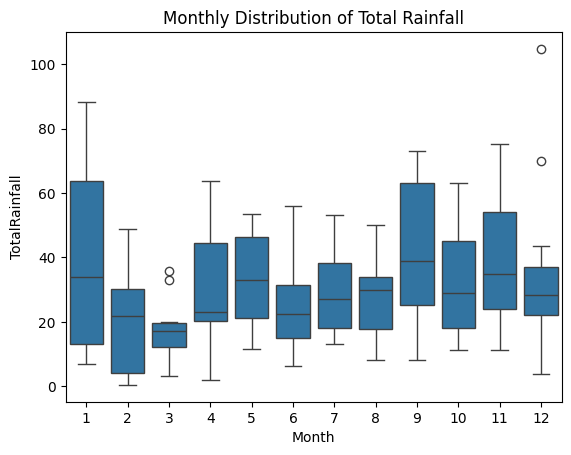

In [28]:
sns.boxplot(x='Month', y='TotalRainfall', data=monthly)
plt.title('Monthly Distribution of Total Rainfall')
plt.show()

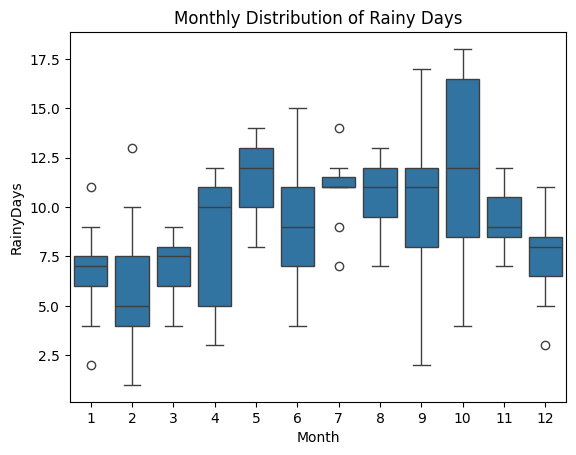

In [29]:
sns.boxplot(x='Month', y='RainyDays', data=monthly)
plt.title('Monthly Distribution of Rainy Days')
plt.show()

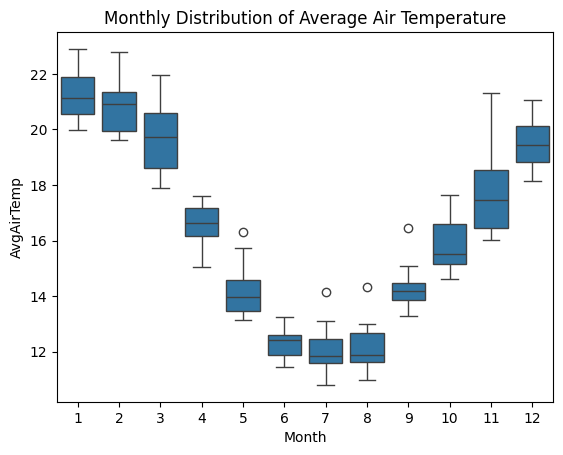

In [30]:
sns.boxplot(x='Month', y='AvgAirTemp', data=monthly)
plt.title('Monthly Distribution of Average Air Temperature')
plt.show()

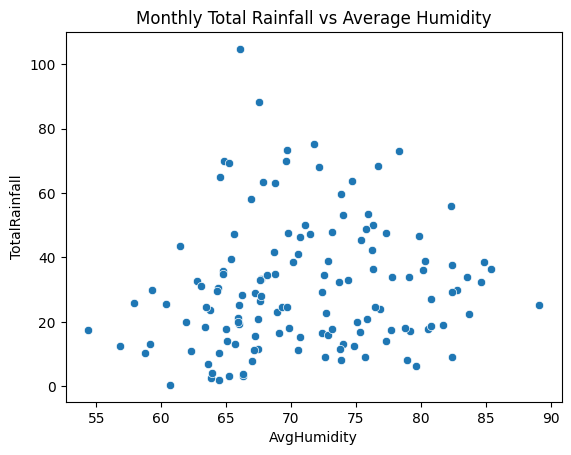

In [31]:
sns.scatterplot(x='AvgHumidity', y='TotalRainfall', data=monthly)
plt.title('Monthly Total Rainfall vs Average Humidity')
plt.show()